In [2]:
!ls

data
face_mask_detection.ipynb
with_mask_42.jpg
with_mask_51.jpg
without_mask_22.jpg
without_mask_31.jpg


In [3]:
pip install numpy matplotlib scikit-learn opencv-python pillow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split

In [5]:
with_mask_files = os.listdir(r'D:\Codes\.vscode\Python\DL\data\with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_1.jpg', 'with_mask_10.jpg', 'with_mask_100.jpg', 'with_mask_1000.jpg', 'with_mask_1001.jpg']
['with_mask_995.jpg', 'with_mask_996.jpg', 'with_mask_997.jpg', 'with_mask_998.jpg', 'with_mask_999.jpg']


In [6]:
without_mask_files = os.listdir(r'D:\Codes\.vscode\Python\DL\data\without_mask')
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_1.jpg', 'without_mask_10.jpg', 'without_mask_100.jpg', 'without_mask_1000.jpg', 'without_mask_1001.jpg']
['without_mask_995.jpg', 'without_mask_996.jpg', 'without_mask_997.jpg', 'without_mask_998.jpg', 'without_mask_999.jpg']


In [7]:
print('Number of images with mask: ',len(with_mask_files))
print('Number of images without mask: ',len(without_mask_files))

Number of images with mask:  3725
Number of images without mask:  3828


In [8]:
#with mask == 1
#without mask == 2
with_mask_labels = [1]*3725
without_mask_labels = [0]*3828

In [9]:
print(with_mask_labels[0:5])
print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [10]:
labels = with_mask_labels + without_mask_labels
print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


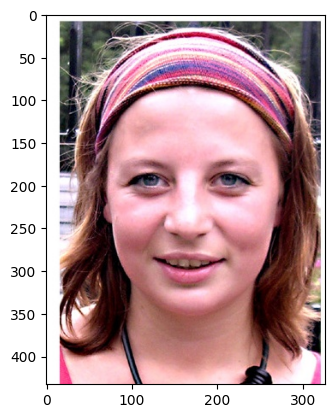

In [11]:
#displaying images
img = mpimg.imread(r'D:\Codes\.vscode\Python\DL\data\without_mask\without_mask_996.jpg')
imgplot = plt.imshow(img)
plt.show()

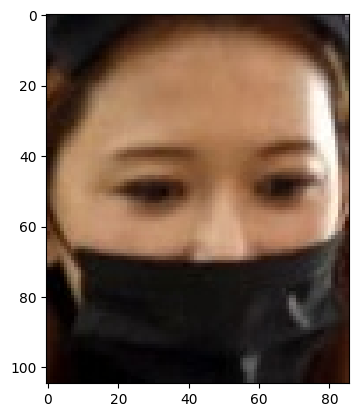

In [12]:
img2 = mpimg.imread(r'D:\Codes\.vscode\Python\DL\data\with_mask\with_mask_100.jpg')
img2plot = plt.imshow(img2)
plt.show()

In [13]:
#convert images to numpy arrays
with_mask_path = 'D:/Codes/.vscode/Python/DL/data/with_mask/'

data = []

for img_file in with_mask_files:

    image = Image.open(with_mask_path + img_file)
    image = image.resize((128,128))
    image = image.convert('RGB')
    image = np.array(image)
    data.append(image)


without_mask_path = 'D:/Codes/.vscode/Python/DL/data/without_mask/'

for img_file in without_mask_files:

    image = Image.open(without_mask_path + img_file)
    image = image.resize((128,128))
    image = image.convert('RGB')
    image = np.array(image)
    data.append(image)

c:\Users\MOHIT\AppData\Local\Programs\Python\Python313\Lib\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [14]:
len(data)

7553

In [15]:
#converting image list and label list to numpy arrays
X = np.array(data)
y = np.array(labels)

In [16]:
print(X.shape)
print(y.shape)

(7553, 128, 128, 3)
(7553,)


In [17]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=2)

In [18]:
print(X.shape, X_train.shape, X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [19]:
#normalizing / scaling
X_train_scaled = X_train/255
X_test_scaled = X_test/255

In [20]:
X_train_scaled[0]

array([[[0.88627451, 0.91764706, 0.78823529],
        [0.82745098, 0.84705882, 0.7372549 ],
        [0.7372549 , 0.7372549 , 0.6627451 ],
        ...,
        [0.72941176, 0.70980392, 0.64705882],
        [0.70196078, 0.68627451, 0.58823529],
        [0.65098039, 0.70980392, 0.53333333]],

       [[0.87843137, 0.89411765, 0.85490196],
        [0.78823529, 0.8       , 0.76470588],
        [0.78823529, 0.78039216, 0.75294118],
        ...,
        [0.77254902, 0.74509804, 0.71372549],
        [0.68627451, 0.66666667, 0.6       ],
        [0.63529412, 0.70588235, 0.56078431]],

       [[0.80392157, 0.8       , 0.83137255],
        [0.86666667, 0.8627451 , 0.88627451],
        [0.76470588, 0.75294118, 0.76862745],
        ...,
        [0.71764706, 0.68235294, 0.67843137],
        [0.6745098 , 0.65490196, 0.62352941],
        [0.70980392, 0.78039216, 0.67058824]],

       ...,

       [[0.61176471, 0.69019608, 0.77254902],
        [0.62352941, 0.70588235, 0.76862745],
        [0.64313725, 0

In [21]:
pip install keras 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import keras

In [23]:
num_of_classes = 2

model = keras.Sequential()

model.add(keras.layers.Conv2D(32,(3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D((2,2)))

model.add(keras.layers.Conv2D(64,(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D((2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(num_of_classes, activation='sigmoid'))

c:\Users\MOHIT\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
#compile
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['acc'])

In [25]:
history = model.fit(X_train_scaled,y_train, validation_split=0.1, epochs=5)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 17s 90ms/step - acc: 0.7861 - loss: 0.4767 - val_acc: 0.8876 - val_loss: 0.2707
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 15s 89ms/step - acc: 0.8839 - loss: 0.2993 - val_acc: 0.8975 - val_loss: 0.2499
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - acc: 0.9036 - loss: 0.2392 - val_acc: 0.9107 - val_loss: 0.2137
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - acc: 0.9207 - loss: 0.2132 - val_acc: 0.9322 - val_loss: 0.1918
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 15s 89ms/step - acc: 0.9351 - loss: 0.1671 - val_acc: 0.9256 - val_loss: 0.2229


In [26]:
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print('Test Accuracy: ',accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9305 - loss: 0.1997
Test Accuracy:  0.9305095672607422


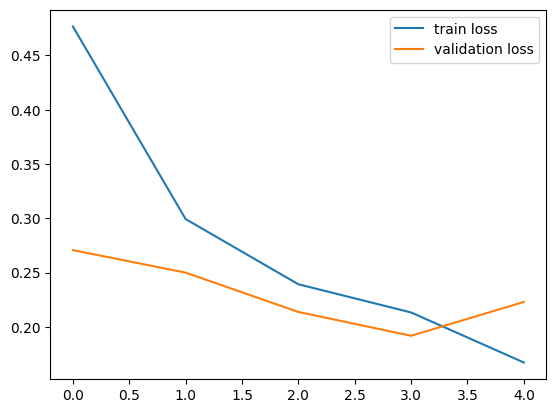

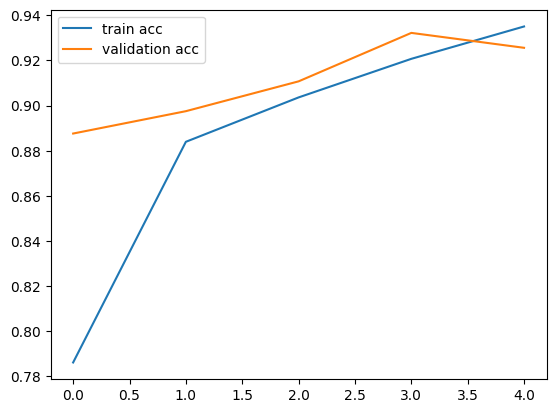

In [27]:
h = history

plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

plt.plot(h.history['acc'], label='train acc')
plt.plot(h.history['val_acc'], label='validation acc')
plt.legend()
plt.show()

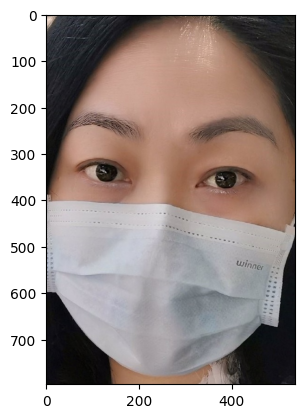

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
[[0.04190538 0.9988048 ]]
1
The person is Wearing the mask


In [28]:
input_image_path = input('Path of the image to be predicted: ')

input_image = mpimg.imread(input_image_path)
imgp= plt.imshow(input_image)
plt.show()

input_image_resized = cv2.resize(input_image, (128,128))
input_image_scaled = input_image_resized/255
input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)
print(input_prediction)

input_pred_label = np.argmax(input_prediction)
print(input_pred_label)


if input_pred_label == 1:
    print('The person is Wearing the mask')
else:
    print('The person is not Wearing the mask')

In [29]:
model.save('mask_detector_model.h5')